In [392]:
import pandas as pd 
import numpy as np


import matplotlib.pyplot as plt

In [393]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [394]:
#!wget $data -O data-week-3.csv

In [395]:
df = pd.read_csv('data-week-3.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [396]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [397]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [398]:
df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


In [399]:
df.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges            str
churn                   str
dtype: object

In [400]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')
tc

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: totalcharges, Length: 7043, dtype: float64

In [401]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

In [402]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [403]:
df.churn = (df.churn == 'Yes').astype(int)

In [404]:
df.churn.head()

0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

# 3.3 Setting up the validation framework

Perform the train/validation/test split with Scikit-Learn

In [405]:
from sklearn.model_selection import train_test_split


In [406]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [407]:
len(df_full_train), len(df_test)

(5634, 1409)

In [408]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [409]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [410]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [411]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [412]:
df_train.head().T

,0,1,2,3,4
customerid,8015-IHCGW,1960-UYCNN,9250-WYPLL,6786-OBWQR,1328-EUZHC
gender,Female,Male,Female,Female,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,Yes,Yes
dependents,Yes,No,No,Yes,No
tenure,72,10,5,5,18
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,Yes,Yes,Yes,No,No
internetservice,Fiber optic,Fiber optic,Fiber optic,Fiber optic,No
onlinesecurity,Yes,No,No,No,No internet service


In [413]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [414]:
df_train.head().T

,0,1,2,3,4
customerid,8015-IHCGW,1960-UYCNN,9250-WYPLL,6786-OBWQR,1328-EUZHC
gender,Female,Male,Female,Female,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,Yes,Yes
dependents,Yes,No,No,Yes,No
tenure,72,10,5,5,18
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,Yes,Yes,Yes,No,No
internetservice,Fiber optic,Fiber optic,Fiber optic,Fiber optic,No
onlinesecurity,Yes,No,No,No,No internet service


In [415]:
df_full_train = df_full_train.reset_index(drop=True)

In [416]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [417]:
df_full_train.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [418]:
df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [419]:
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate,2)

np.float64(0.27)

In [420]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [421]:
numerical =['tenure', 'monthlycharges', 'totalcharges']

In [422]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [423]:
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [424]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

3.5. Feature importance: Churn rate and risk ratio

Churn rate

In [425]:
df_full_train.head().T

,0,1,2,3,4
customerid,5442-PPTJY,6261-RCVNS,2176-OSJUV,6161-ERDGD,2364-UFROM
gender,Male,Female,Male,Male,Male
seniorcitizen,0,0,0,0,0
partner,Yes,No,Yes,Yes,No
dependents,Yes,No,No,Yes,No
tenure,12,42,71,71,30
phoneservice,Yes,Yes,Yes,Yes,Yes
multiplelines,No,No,Yes,Yes,No
internetservice,No,DSL,DSL,DSL,DSL
onlinesecurity,No internet service,Yes,Yes,Yes,Yes


In [426]:
churn_female = df_full_train[df_full_train.gender == 'Female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [427]:
churn_male = df_full_train[df_full_train.gender == 'Male'].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [428]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [429]:
churn_partner = df_full_train[df_full_train.partner == 'Yes'].churn.mean()

In [430]:
churn_no_partner = df_full_train[df_full_train.partner == 'No'].churn.mean()

In [431]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [432]:
global_churn - churn_partner


np.float64(0.06493474245795922)

In [433]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

Risk ratio

In [434]:
churn_no_partner/global_churn 

np.float64(1.2216593879412643)

In [435]:
churn_partner/global_churn 

np.float64(0.7594724924338315)

In [436]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn
df_group['diff_ratio'] = df_group['mean']/global_churn
df_group

,mean,count,diff,diff_ratio
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980


In [437]:
from IPython.display import display

In [438]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['diff_ratio'] = df_group['mean']/global_churn
    display(df_group)
    print()

gender


,mean,count,diff,diff_ratio
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980



seniorcitizen


,mean,count,diff,diff_ratio
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208



partner


...

,mean,count,diff,diff_ratio
contract,,,,
Month-to-month,0.431701,3104,0.161733,1.599082
One year,0.120573,1186,-0.149395,0.446621
Two year,0.028274,1344,-0.241694,0.104730



paperlessbilling


,mean,count,diff,diff_ratio
paperlessbilling,,,,
No,0.172071,2313,-0.097897,0.637375
Yes,0.338151,3321,0.068183,1.252560



paymentmethod


,mean,count,diff,diff_ratio
paymentmethod,,,,
Bank transfer (automatic),0.168171,1219,-0.101797,0.622928
Credit card (automatic),0.164339,1217,-0.105630,0.608733
Electronic check,0.455890,1893,0.185922,1.688682
Mailed check,0.193870,1305,-0.076098,0.718121


3.6 Feature importance: Mutual information

In [439]:
from sklearn.metrics import mutual_info_score

In [440]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [441]:
mutual_info_score(df_full_train.churn, df_full_train.gender)

0.0001174846211139946

In [442]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

0.009967689095399745

In [443]:
def mutual_info_churn_score(series):
    return mutual_info_score(df_full_train.churn, series)

In [444]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

3.7 Feature importance: Correlation

In [445]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [446]:
df_full_train[df_full_train.tenure < 2].churn.mean()

np.float64(0.6247464503042597)

3.8 One hot encoding

In [447]:
from sklearn.feature_extraction import DictVectorizer


In [448]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

3.9 Logistic Regression

In [449]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [450]:
z = np.linspace(-7, 7, 51)

In [451]:
sigmoid(10000)

np.float64(1.0)

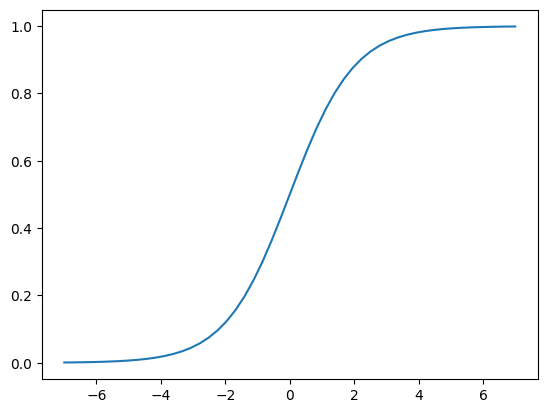

In [452]:
plt.plot(z, sigmoid(z))

In [453]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
        
    return result

In [454]:
def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]
        
    result = sigmoid(score)
    return result

3.10 Training Logistic Regression with Scikit-learn

In [455]:
from sklearn.linear_model import LogisticRegression

In [456]:
model = LogisticRegression(solver='lbfgs')
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [457]:
model.coef_[0].round(3)

array([ 0.564, -0.154, -0.519, -0.013, -0.095,  0.071, -0.098, -0.082,
       -0.033, -0.076, -0.354,  0.343, -0.098,  0.002, -0.251,  0.162,
       -0.02 ,  0.066, -0.098, -0.076,  0.251, -0.098, -0.261, -0.228,
        0.119, -0.121,  0.012, -0.095, -0.03 ,  0.045, -0.028,  0.162,
       -0.271,  0.221, -0.097, -0.098,  0.087, -0.05 , -0.098,  0.039,
        0.194, -0.098, -0.205, -0.072,  0.   ])

In [458]:
model.intercept_[0]

np.float64(-0.1109287445794238)

In [459]:
y_pred = model.predict_proba(X_val)[:, 1]

In [460]:
churn_decision = (y_pred >= 0.5)

In [461]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

In [462]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [463]:
df_pred

,probability,prediction,actual
0,0.007863,0,0
1,0.209928,0,0
2,0.223710,0,0
3,0.561123,1,1
4,0.219586,0,0
...,...,...,...
1404,0.297790,0,0
1405,0.035463,0,1
1406,0.150149,0,0
1407,0.776681,1,1


In [464]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [465]:
df_pred

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True
...,...,...,...,...
1404,0.297790,0,0,True
1405,0.035463,0,1,False
1406,0.150149,0,0,True
1407,0.776681,1,1,True


In [466]:
df_pred.correct.mean()

np.float64(0.801277501774308)

In [467]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [468]:
df_val[churn_decision].customerid

3       8433-WXGNA
8       3440-JPSCL
11      2637-FKFSY
12      7228-OMTPN
19      6711-FLDFB
           ...    
1397    5976-JCJRH
1398    2034-CGRHZ
1399    5276-KQWHG
1407    6521-YYTYI
1408    3049-SOLAY
Name: customerid, Length: 322, dtype: str

In [469]:
y_val

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [470]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1], shape=(1409,))

In [471]:
(y_val == churn_decision.astype(int)).mean()

np.float64(0.801277501774308)

3.11 Model Interpretation

In [472]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=Month-to-month': np.float64(0.564),
 'contract=One year': np.float64(-0.154),
 'contract=Two year': np.float64(-0.519),
 'dependents=No': np.float64(-0.013),
 'dependents=Yes': np.float64(-0.095),
 'deviceprotection=No': np.float64(0.071),
 'deviceprotection=No internet service': np.float64(-0.098),
 'deviceprotection=Yes': np.float64(-0.082),
 'gender=Female': np.float64(-0.033),
 'gender=Male': np.float64(-0.076),
 'internetservice=DSL': np.float64(-0.354),
 'internetservice=Fiber optic': np.float64(0.343),
 'internetservice=No': np.float64(-0.098),
 'monthlycharges': np.float64(0.002),
 'multiplelines=No': np.float64(-0.251),
 'multiplelines=No phone service': np.float64(0.162),
 'multiplelines=Yes': np.float64(-0.02),
 'onlinebackup=No': np.float64(0.066),
 'onlinebackup=No internet service': np.float64(-0.098),
 'onlinebackup=Yes': np.float64(-0.076),
 'onlinesecurity=No': np.float64(0.251),
 'onlinesecurity=No internet service': np.float64(-0.098),
 'onlinesecurity=Yes

In [473]:
small = ['contract', 'tenure', 'monthlycharges']

In [474]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'Two year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'Month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'Month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'Two year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'Month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'Month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'Two year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'Month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [475]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [476]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [477]:
dv_small.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'monthlycharges', 'tenure'], dtype=object)

In [478]:
X_train_small = dv_small.transform(dicts_train_small)

In [479]:
model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [480]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957595829565)

In [481]:
w = model_small.coef_[0]
w.round(3)

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [482]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=Month-to-month': np.float64(0.971),
 'contract=One year': np.float64(-0.024),
 'contract=Two year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [483]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

-3.473

In [484]:
sigmoid(_)

np.float64(0.030090303318277657)

3.12 Using the model

In [485]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [486]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [487]:
y_full_train = df_full_train.churn.values

In [488]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [489]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [490]:
X_test = dv.transform(dicts_test)

In [491]:
y_pred = model.predict_proba(X_test)[:, 1]

In [492]:
churn_decision = (y_pred >= 0.5)

In [493]:
(churn_decision == y_test).mean()

np.float64(0.8140525195173882)

In [494]:
y_test

array([0, 0, 0, ..., 0, 0, 1], shape=(1409,))

In [495]:
customer = dicts_test[-1]
customer

{'gender': 'Female',
 'seniorcitizen': 0,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'Yes',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'Yes',
 'onlinebackup': 'No',
 'deviceprotection': 'Yes',
 'techsupport': 'No',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Month-to-month',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Electronic check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [496]:
X_small = dv.transform([customer])

In [497]:
model.predict_proba(X_small)[0, 1]

np.float64(0.6613470087309817)

In [ ]:
y_test[-1]